# MSFT Weekly Direction Predictor — Model Training Notebook

**Task:** predict the **direction of Microsoft's (MSFT) stock one week ahead**,
as a three-class problem — `DOWN (0)`, `UP (1)`, or `NEUTRAL (2)` — where
NEUTRAL covers weekly moves within ±1%.

This notebook documents the full model-development process and compares four
approaches on identical inputs: a **majority-class baseline**, a
**Random Forest**, a **tuned XGBoost** classifier, and an **LSTM** sequence
model. All data preparation is delegated to the project's reusable
`data_handling.py` module so the same, tested preprocessing feeds every model.

---

### How this notebook is organised
It follows the eleven sections of the course template: problem definition →
data → validation strategy → baseline → candidate models → evaluation
framework → training → iteration → error analysis → validation results → final
selection.

### Deliverable alignment
- **ILO 8.4 A** — *why the model is an appropriate solution* → §5, §11.2
- **ILO 8.4 B** — *metrics, validation performance, limitations, errors* →
  §6, §9, §10, §11.3
- **ILO 8.4 C** — *key iterations and how they improved performance* → §8, §11.4

> **Individual-work note.** This notebook reflects my own modelling choices
> (weekly 3-class target, peer-stock features, XGBoost focus). It is intended
> to be distinct from other group members' submissions.

## 0. Project metadata

- **Project title:** MSFT Weekly Direction Predictor (3-class)
- **Notebook owner / author:** Timur Kambarov
- **Student number:** 250596
- **Group:** Group 15 — Block D, ADS-AI, BUas
- **Date:** `TODO`
- **Dataset:** `modelling_dataset.csv` (merged MSFT + peer tickers)
- **Repository:** individual GitHub repo (rename this file to
  `model_training_notebook_<student_number>.ipynb` before submitting)

## Environment, imports and configuration

The data-preparation functions live in `data_handling.py` (the project's
tested data layer); this notebook only imports and calls them, which keeps the
modelling logic and the data logic cleanly separated. A single random seed is
fixed everywhere for reproducibility.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import logging
import warnings
from pathlib import Path

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

# ── Gradient boosting + tuning ────────────────────────────────────────────────
import optuna
from xgboost import XGBClassifier

# ── Deep learning (LSTM) ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Project data layer ────────────────────────────────────────────────────────
import data_handling as dh

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_modelling")

# ── Plot style ────────────────────────────────────────────────────────────────
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13

# ── Project configuration ─────────────────────────────────────────────────────
# EDIT THIS PATH to point at the merged modelling dataset on your machine.
DATA_PATH = Path("../../data/processed/modelling_dataset.csv")
OUTPUT_DIR = Path("models")

CLASS_NAMES = ["DOWN", "UP", "NEUTRAL"]          # index == integer label
CLASS_LABELS = [0, 1, 2]
FEATURE_COLUMNS = dh.build_feature_columns()      # 12 base + 4 per peer ticker

logger.info("TensorFlow %s | features: %d", tf.__version__, len(FEATURE_COLUMNS))

c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-10 22:07:45 | INFO | TensorFlow 2.21.0 | features: 20


## 1. Problem definition

### 1.1 Prediction or analysis task
- **Task.** Multiclass classification of MSFT's **next-week** price direction
  into `DOWN (0)`, `UP (1)`, `NEUTRAL (2)`. The NEUTRAL band (±1% weekly move)
  separates economically meaningful moves from noise, which a plain binary
  up/down target would force into one side or the other.
- **Inputs available at prediction time.** Only information known at the close
  of the current week `t`: MSFT momentum (1/4/8-week returns, lagged returns),
  oscillators (RSI-14, MACD and its signal/histogram), volatility
  (5-week rolling std, weekly high–low range), a volume ratio, and peer-stock
  signals for NVDA and AMZN (their returns, relative strength vs MSFT, and
  volume pressure). No future or same-future-week data is used.
- **Output.** A single class label for week `t+1`, plus class probabilities
  the dashboard can surface as confidence.
- **Users.** The group's trading-insight dashboard and, through it, a
  retail-style user weighing a weekly hold/reduce decision on MSFT.

### 1.2 Business or project value
- **Decision supported.** A weekly directional view that contextualises the
  dashboard's other indicators — *is the coming week more likely up, down, or
  flat?*
- **If it works well.** Users get an evidence-based, repeatable signal instead
  of reacting to headlines; the NEUTRAL class explicitly flags low-conviction
  weeks where sitting still is sensible.
- **Risk if it performs poorly.** Misleading confidence could prompt poor
  trades. We therefore treat the output as **decision support, not advice**,
  report honest uncertainty, and keep a simple baseline as a sanity check.

### 1.3 Success criteria
- **Primary metric: macro-averaged F1.** The three classes are imbalanced
  (NEUTRAL is rarest), and each class matters, so macro-F1 — which weights all
  classes equally — is the metric we optimise and compare on.
- **Bar to clear.** Beat the majority-class baseline's macro-F1 by a clear
  margin, and beat the naïve accuracy of always predicting the largest class.
- **Other constraints.** Reasonable interpretability (feature importances we
  can explain to users), fast weekly inference, and stability across time
  periods rather than a single lucky split.

## 2. Data selection and preparation

### 2.1 Dataset summary
- **Data source(s):** `modelling_dataset.csv` — a merged daily price/volume
  table for MSFT plus peer tickers (NVDA, AMZN), produced by the project's
  data-collection pipeline.
- **Collection period:** 2020-01-01 onward (earlier rows are filtered out so
  every model trains on the same window).
- **Unit of analysis:** **one trading week** (week ending Friday) after
  resampling from daily bars.
- **Target variable:** `Direction` — next-week move, `0 = DOWN`, `1 = UP`,
  `2 = NEUTRAL` (|move| ≤ 1%).
- **Key features:** MSFT momentum/oscillator/volatility/volume features plus
  four scale-invariant signals per peer ticker (see §2.4).
- **Important exclusions/filters:** rows before 2020; non-trading days are
  used only to forward-fill, never resampled directly; warm-up weeks with
  incomplete look-backs and the final unlabelled week are dropped.

### 2.2 Risks and limitations
- **Missing values.** Calendar gaps are forward-filled; warm-up NaNs from
  rolling windows are dropped; a final median/mode pass guarantees a complete
  matrix. Forward-fill can carry a stale price across holidays — accepted as a
  minor, well-understood approximation.
- **Sampling bias.** A single ticker over one regime (2020–present, a largely
  bullish, high-volatility tech period). The model may not transfer to other
  regimes or stocks.
- **Label-quality issues.** The ±1% NEUTRAL threshold is a modelling choice;
  it directly controls class balance and is revisited in §8.
- **Leakage risks.** Every feature uses only data up to the close of week `t`;
  the target looks one week ahead; the split is strictly time-ordered and the
  scaler is fit on training data only.
- **Ethical/financial concerns.** Output is decision support, not financial
  advice; past performance does not guarantee future results.

In [2]:
# Load the merged dataset (raw, daily) via the tested data layer.
df_raw = dh.load_dataset(DATA_PATH)
logger.info("Raw shape: %s", df_raw.shape)
df_raw.head()

2026-06-10 22:07:46 | INFO | Loaded 1613 rows from ..\..\data\processed\modelling_dataset.csv (>= 2020-01-01)
2026-06-10 22:07:46 | INFO | Raw shape: (1613, 22)


,Date,msft_open,msft_high,msft_low,msft_close,msft_volume,gold_close,gold_volume,vix_close,vix_volume,...,nvda_close,nvda_volume,amd_close,amd_volume,amzn_close,amzn_volume,crm_close,crm_volume,pltr_close,pltr_volume
252,2020-01-02,150.090217,151.933494,149.664848,151.829514,22622100.0,1524.500000,214.0,12.47,0.0,...,5.963804,237536000.0,49.099998,80331100.0,94.900497,80580000.0,164.573807,5189300.0,9.5,338584400.0
253,2020-01-03,149.655425,151.196208,149.409646,149.938995,21116200.0,1549.199951,107.0,14.02,0.0,...,5.868347,205384000.0,48.599998,73127400.0,93.748497,75288000.0,163.765640,3205400.0,9.5,338584400.0
254,2020-01-06,148.483307,150.392760,147.944495,150.326584,20813700.0,1566.199951,416.0,13.85,0.0,...,5.892958,262636000.0,48.389999,47934900.0,95.143997,81236000.0,170.940308,8836200.0,9.5,338584400.0
255,2020-01-07,150.600711,150.931547,148.710167,148.955933,21634100.0,1571.800049,47.0,13.79,0.0,...,5.964301,314856000.0,48.250000,58061400.0,95.343002,80898000.0,173.453400,8272700.0,9.5,338584400.0
256,2020-01-08,150.231988,151.999656,149.305626,151.328506,27746500.0,1557.400024,236.0,13.45,0.0,...,5.975488,277108000.0,47.830002,53767000.0,94.598503,70160000.0,174.764175,7225100.0,9.5,338584400.0


### 2.3 Initial data inspection
We check the raw frame before transforming it: how many rows/columns, the date
span, the data types, whether the expected peer columns are present, and how
many values are missing. The target's class balance is reported *after* feature
engineering (the target does not exist in the raw feed).

In [3]:
# Basic raw-data inspection.
print("Shape:", df_raw.shape)
print("\nDate range:", df_raw["Date"].min(), "->", df_raw["Date"].max())

print("\nColumns and dtypes:")
print(df_raw.dtypes)

expected_peer_cols = [f"{p}_{s}" for p in dh.PEER_TICKERS for s in ("close", "volume")]
present = [c for c in expected_peer_cols if c in df_raw.columns]
print("\nPeer columns present:", present)

missing_raw = int(df_raw.isna().sum().sum())
print("\nTotal missing values (raw):", missing_raw)

df_raw.describe().T

Shape: (1613, 22)

Date range: 2020-01-02 -> 2026-05-29

Columns and dtypes:
Date               str
msft_open      float64
msft_high      float64
msft_low       float64
msft_close     float64
msft_volume    float64
gold_close     float64
gold_volume    float64
vix_close      float64
vix_volume     float64
asml_close     float64
asml_volume    float64
nvda_close     float64
nvda_volume    float64
amd_close      float64
amd_volume     float64
amzn_close     float64
amzn_volume    float64
crm_close      float64
crm_volume     float64
pltr_close     float64
pltr_volume    float64
dtype: object

Peer columns present: ['nvda_close', 'nvda_volume', 'amzn_close', 'amzn_volume']

Total missing values (raw): 0


,count,mean,std,min,25%,50%,75%,max
msft_open,1613.0,3.211674e+02,1.008610e+02,1.298654e+02,2.376361e+02,3.079360e+02,4.092561e+02,5.508302e+02
msft_high,1613.0,3.242735e+02,1.012650e+02,1.332398e+02,2.402619e+02,3.113823e+02,4.121573e+02,5.510485e+02
msft_low,1613.0,3.179403e+02,1.002484e+02,1.256096e+02,2.353117e+02,3.049931e+02,4.049558e+02,5.373667e+02
msft_close,1613.0,3.212442e+02,1.007786e+02,1.283583e+02,2.376640e+02,3.070391e+02,4.090293e+02,5.386585e+02
msft_volume,1613.0,2.806645e+07,1.265873e+07,5.855900e+06,1.993780e+07,2.497020e+07,3.255090e+07,1.288553e+08
gold_close,1613.0,2.357274e+03,8.895275e+02,1.477300e+03,1.801100e+03,1.933500e+03,2.634900e+03,5.318400e+03
gold_volume,1613.0,4.321048e+03,2.246916e+04,0.000000e+00,9.500000e+01,3.070000e+02,8.250000e+02,2.512740e+05
vix_close,1613.0,2.091643e+01,7.709934e+00,1.186000e+01,1.604000e+01,1.897000e+01,2.402000e+01,8.269000e+01
vix_volume,1613.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
asml_close,1613.0,6.910570e+02,2.712566e+02,1.859776e+02,5.372430e+02,6.634716e+02,7.889691e+02,1.632900e+03


### 2.4 Preprocessing decisions
All steps below are implemented in `data_handling.py` and called here, so the
notebook and any production script share one tested code path.

- **Missing values.** Daily calendar reindex + forward-fill for gaps; rolling
  warm-up rows dropped; final median/mode pass as a safety net.
- **Categorical encoding.** None needed — every feature is numeric.
- **Scaling.** `RobustScaler` (median/IQR) is applied in §3 because the
  features contain outliers (volatility spikes) that would distort a standard
  scaler; it is fit on the training split only.
- **Feature engineering.** Raw price *levels* are non-stationary and excluded.
  We engineer **scale-invariant** features only: returns over 1/4/8 weeks,
  lagged returns, RSI-14, MACD (+signal, +histogram), weekly high–low range,
  5-week rolling volatility, and a 20-week volume ratio. Each peer adds its own
  weekly return, that return lagged one week, its **relative strength** vs MSFT,
  and a volume ratio — capturing whether MSFT leads or lags the tech complex.
- **Leakage-driven removals.** Price levels and any same-or-future-week
  information are deliberately not used.
- **Time-based split.** Yes — chronological, no shuffling (see §3).
- **Resampling.** Daily → weekly (week-ending-Friday): MSFT keeps full OHLCV;
  peers contribute summed volume and last close.

2026-06-10 22:07:46 | INFO | Loaded 1613 rows from ..\..\data\processed\modelling_dataset.csv (>= 2020-01-01)
2026-06-10 22:07:46 | INFO | Aligned to NYSE calendar: 2340 daily rows
2026-06-10 22:07:46 | INFO | Resampled to 335 weekly bars (2020-01-03 to 2026-05-29)
2026-06-10 22:07:46 | INFO | Target balance - DOWN(0): 109 | UP(1): 132 | NEUTRAL(2): 75
2026-06-10 22:07:46 | INFO | Total missing values: 0
2026-06-10 22:07:46 | INFO | Preprocessing complete: 316 weekly rows ready.
2026-06-10 22:07:46 | INFO | Modelling frame: (316, 43)


Class balance:
 DOWN       109
UP         132
NEUTRAL     75
Name: count, dtype: int64 



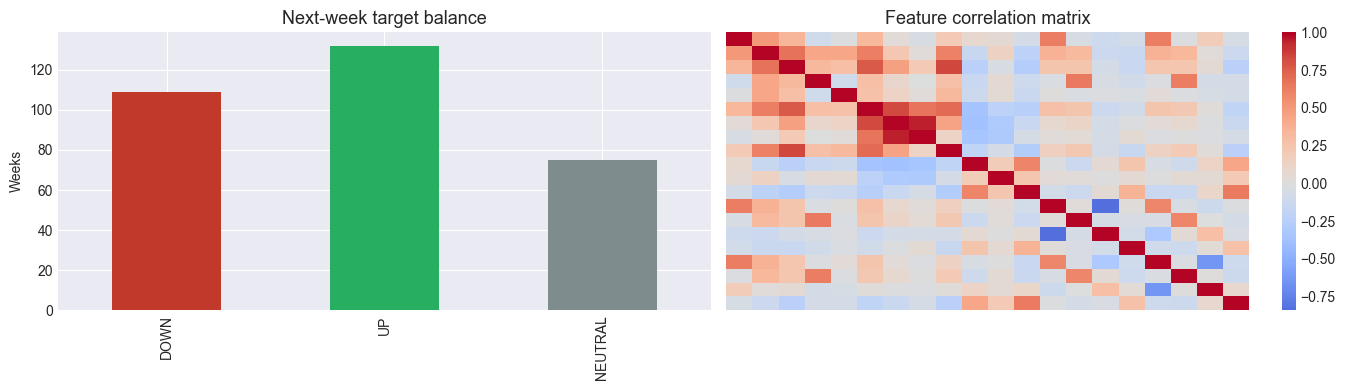

In [4]:
# Run the full preprocessing pipeline:
#   load -> align to NYSE calendar -> weekly resample -> engineer features
#   -> fill residual missing values.  (df_raw is reloaded inside preprocess.)
df = dh.preprocess(DATA_PATH)
logger.info("Modelling frame: %s", df.shape)

# Target class balance.
balance = df["Direction"].value_counts().sort_index()
balance.index = [CLASS_NAMES[i] for i in balance.index]
print("Class balance:\n", balance, "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
balance.plot(kind="bar", color=["#c0392b", "#27ae60", "#7f8c8d"], ax=axes[0])
axes[0].set_title("Next-week target balance")
axes[0].set_ylabel("Weeks")

# Feature correlation heatmap (quick multicollinearity scan).
corr = df[FEATURE_COLUMNS].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1],
            xticklabels=False, yticklabels=False)
axes[1].set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 3. Validation strategy

### 3.1 Chosen validation approach
**Time-based hold-out split** for headline reporting, plus **`TimeSeriesSplit`
cross-validation** (§10) for stability. This is a forecasting problem: rows are
ordered in time and adjacent weeks are correlated, so a random or stratified
shuffle would let the model peek at the future and inflate scores. A
chronological split — train on the past, test on the most recent ~15% — mirrors
how the model is actually used.

### 3.2 Leakage prevention
- **No shuffling:** the test set is strictly later than the training set.
- **Feature timing:** every feature uses only information up to the close of
  week `t`; the label looks ahead to `t+1`.
- **Scaler discipline:** `RobustScaler` is fit on the training split only and
  then applied to the test split; in cross-validation it is re-fit inside a
  `Pipeline` on each fold's training portion.

In [5]:
# Time-ordered split + train-only scaling (implemented in data_handling).
X_train, X_test, y_train, y_test, scaler = dh.split_and_scale(df, FEATURE_COLUMNS)

# Keep the matching dataframe slices for time-aware error analysis later.
n_test = len(y_test)
df_test = df.iloc[-n_test:].copy()

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train period:", df["Date"].iloc[0].date(),
      "->", df["Date"].iloc[len(y_train) - 1].date())
print("Test  period:", df_test["Date"].iloc[0].date(),
      "->", df_test["Date"].iloc[-1].date())

2026-06-10 22:07:47 | INFO | Training matrix: 316 rows x 20 features
2026-06-10 22:07:47 | INFO | Split - train: 268 samples | test: 48 samples


Train: (268, 20) | Test: (48, 20)
Train period: 2020-05-15 -> 2025-06-27
Test  period: 2025-07-04 -> 2026-05-29


## 4. Baseline model

### 4.1 Baseline approach
A **majority-class** classifier (`DummyClassifier(strategy="most_frequent")`):
it always predicts the most common class in the training data. This is the
honest minimum bar — any useful model must beat it on macro-F1. Because it
predicts a single class, its macro-F1 is structurally low even when its raw
accuracy looks deceptively high, which is exactly why macro-F1 is our primary
metric.

In [6]:
# Shared evaluation helpers (used by every model below).
results = []  # collects one dict per model for the comparison table


def evaluate_model(y_true, y_pred, model_name, store=True):
    """Compute macro-averaged metrics, log them, and optionally store.

    Macro averaging weights each of the three classes equally, matching the
    project's success criterion.
    """
    metrics = {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(
            precision_score(y_true, y_pred, average="macro", zero_division=0), 4
        ),
        "Recall": round(
            recall_score(y_true, y_pred, average="macro", zero_division=0), 4
        ),
        "MacroF1": round(f1_score(y_true, y_pred, average="macro"), 4),
    }
    logger.info(
        "%-22s Acc %.4f | Prec %.4f | Rec %.4f | macroF1 %.4f",
        model_name, metrics["Accuracy"], metrics["Precision"],
        metrics["Recall"], metrics["MacroF1"],
    )
    if store:
        results.append(metrics)
    return metrics


def plot_confusion(y_true, y_pred, title):
    """Plot a 3-class confusion matrix with counts and row-percentages."""
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1) * 100
    annot = np.array([
        [f"{cm[i, j]}\n({cm_pct[i, j]:.0f}%)" for j in range(3)]
        for i in range(3)
    ])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Fit and evaluate the baseline.
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
evaluate_model(y_test, y_pred_dummy, "Baseline (Majority)")

2026-06-10 22:07:47 | INFO | Baseline (Majority)    Acc 0.3333 | Prec 0.1111 | Rec 0.3333 | macroF1 0.1667


{'Model': 'Baseline (Majority)',
 'Accuracy': 0.3333,
 'Precision': 0.1111,
 'Recall': 0.3333,
 'MacroF1': 0.1667}

### 4.2 Baseline results
The metrics for the baseline are printed by the cell above and collected into
`results` (shown together in the §7.1 comparison table).

**Interpretation.** The baseline's macro-F1 is low because predicting one class
scores zero F1 on the two it never predicts. Its accuracy equals the share of
the majority class. Any candidate model has to beat **both** of these numbers
to justify its added complexity.

## 5. Candidate models

| Model | Why suitable | Key strengths | Main risks / limitations |
|---|---|---|---|
| **Random Forest** | Strong, low-tuning tabular classifier; bagged trees handle non-linear feature interactions | Robust to outliers/scale; `class_weight` handles imbalance; gives feature importances | Can overfit noise; less expressive of temporal order |
| **XGBoost** | State-of-the-art gradient boosting for tabular data; the project's primary model | High accuracy; per-sample weighting for imbalance; regularisation; importances | More hyper-parameters; needs careful CV to avoid overfitting |
| **LSTM** | Recurrent net designed for *sequences*; can learn temporal patterns across recent weeks | Models order/memory the tree models cannot | Data-hungry; ~300 weekly rows is small; slower; less interpretable |

**Selection rationale.** The two tree ensembles are excellent tabular
baselines and are directly comparable (same engineered features). The LSTM
tests whether explicitly modelling the *sequence* of recent weeks adds value
beyond hand-built lag features — an honest check given our limited sample size.
XGBoost is the project's primary candidate; Random Forest and the LSTM are the
sibling comparisons (ILO 8.4 A).

## 6. Evaluation framework

### 6.1 Primary metric
**Macro-averaged F1.** With three imbalanced classes and a rare NEUTRAL class,
macro-F1 forces a model to do well on *every* class, not just the largest. It
is the score we optimise during tuning (§8) and rank models by.

### 6.2 Secondary metrics
- **Accuracy** — intuitive, but inflated by the majority class; reported for
  context only.
- **Macro precision / recall** — show whether errors are false alarms vs
  misses, per class.
- **Per-class precision/recall/F1** (`classification_report`) and the
  **confusion matrix** — reveal *which* classes are confused (key for §9).

## 7. Train and evaluate models

Each candidate is trained on the scaled training split and evaluated on the
held-out test split. Class imbalance is addressed with **balanced sample
weights** (trees) or **class weights** (LSTM) rather than resampling, so no
synthetic or duplicated weeks are introduced.

2026-06-10 22:07:48 | INFO | Random Forest          Acc 0.2708 | Prec 0.1842 | Rec 0.2635 | macroF1 0.2164


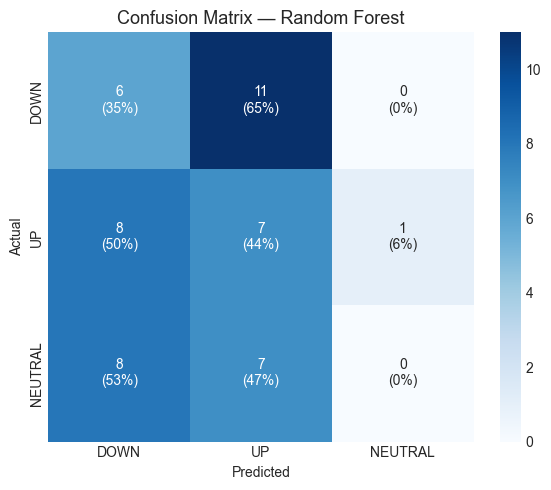

In [7]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    class_weight="balanced",   # counteract the rare NEUTRAL class
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(y_test, y_pred_rf, "Random Forest")
plot_confusion(y_test, y_pred_rf, "Confusion Matrix — Random Forest")

2026-06-10 22:07:51 | INFO | XGBoost (untuned)      Acc 0.3750 | Prec 0.4095 | Rec 0.3667 | macroF1 0.3464


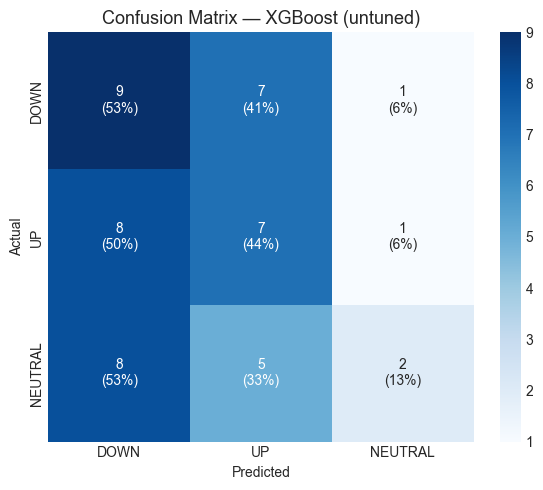

In [8]:
# ── XGBoost (default-ish params; tuned in §8) ─────────────────────────────────
sample_weight = compute_sample_weight("balanced", y_train)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.001,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train, sample_weight=sample_weight)
y_pred_xgb = xgb_model.predict(X_test).astype(int)
evaluate_model(y_test, y_pred_xgb, "XGBoost (untuned)")
plot_confusion(y_test, y_pred_xgb, "Confusion Matrix — XGBoost (untuned)")

2026-06-10 22:07:51 | WARNING | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-06-10 22:07:59 | INFO | LSTM trained for 18 epochs (early stopping).
2026-06-10 22:07:59 | INFO | LSTM                   Acc 0.3250 | Prec 0.3268 | Rec 0.3107 | macroF1 0.3121


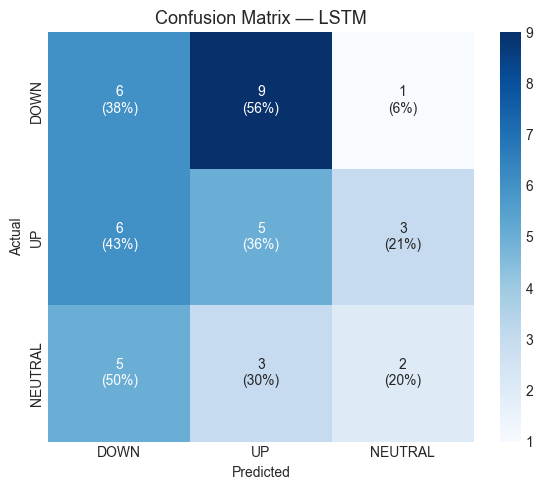

In [9]:
# ── LSTM ──────────────────────────────────────────────────────────────────────
# Recurrent nets need *sequences*: each sample is a window of WINDOW consecutive
# weeks of features. Train and test windows are built separately so no test
# information leaks across the split boundary.
WINDOW = 8


def make_sequences(features, targets, window):
    """Turn a (rows, features) matrix into (samples, window, features)."""
    X_seq, y_seq = [], []
    targets = np.asarray(targets)
    for i in range(window, len(features)):
        X_seq.append(features[i - window:i])
        y_seq.append(targets[i])
    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = make_sequences(X_train, y_train.values, WINDOW)
X_test_seq, y_test_seq = make_sequences(X_test, y_test.values, WINDOW)

# Class weights compensate for imbalance during training.
cw = compute_class_weight("balanced", classes=np.unique(y_train_seq), y=y_train_seq)
class_weight = {int(c): float(w) for c, w in zip(np.unique(y_train_seq), cw)}

lstm = models.Sequential([
    layers.Input(shape=(WINDOW, X_train.shape[1])),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax"),
])
lstm.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])

early = callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                restore_best_weights=True)
history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=120, batch_size=16,
    class_weight=class_weight,
    callbacks=[early], verbose=0,
)
logger.info("LSTM trained for %d epochs (early stopping).", len(history.history["loss"]))

y_pred_lstm = lstm.predict(X_test_seq, verbose=0).argmax(axis=1)
evaluate_model(y_test_seq, y_pred_lstm, "LSTM")
plot_confusion(y_test_seq, y_pred_lstm, "Confusion Matrix — LSTM")

### 7.1 Model comparison summary
The table below is generated live from the `results` collected above.

,Model,Accuracy,Precision,Recall,MacroF1,Beats baseline?
0,XGBoost (untuned),0.3750,0.4095,0.3667,0.3464,yes
1,LSTM,0.3250,0.3268,0.3107,0.3121,yes
2,Random Forest,0.2708,0.1842,0.2635,0.2164,yes
3,Baseline (Majority),0.3333,0.1111,0.3333,0.1667,no


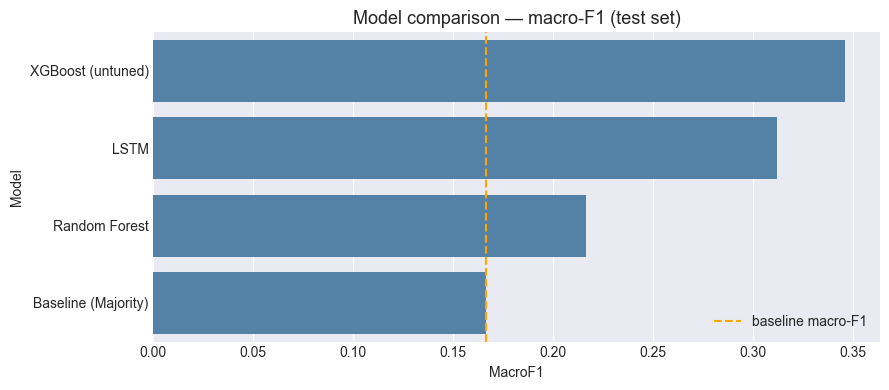

In [10]:
comparison_df = pd.DataFrame(results).sort_values("MacroF1", ascending=False)
baseline_f1 = comparison_df.loc[
    comparison_df["Model"] == "Baseline (Majority)", "MacroF1"
].iloc[0]
comparison_df["Beats baseline?"] = np.where(
    comparison_df["MacroF1"] > baseline_f1, "yes", "no"
)
display(comparison_df.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=comparison_df, x="MacroF1", y="Model", color="steelblue", ax=ax)
ax.axvline(baseline_f1, color="orange", ls="--", label="baseline macro-F1")
ax.set_title("Model comparison — macro-F1 (test set)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** Read the chart against the orange baseline line: models to
its right add genuine signal. We expect both tree ensembles to clear the
baseline comfortably; the LSTM is the wildcard given the small sample. The
leading tree model is carried into tuning (§8). *(Exact numbers come from the
run above.)*

## 8. Iteration and improvement

The headline iteration is **hyper-parameter tuning of XGBoost with Optuna**,
using `TimeSeriesSplit` cross-validation and macro-F1 as the objective, with
balanced sample weights re-computed on each fold. Earlier qualitative
iterations (peer features, class weighting, the NEUTRAL threshold) are recorded
in the log below.

2026-06-10 22:08:42 | INFO | Best CV macro-F1: 0.3420
2026-06-10 22:08:42 | INFO | Best params: {'n_estimators': 138, 'max_depth': 7, 'learning_rate': 0.007351054878769578, 'subsample': 0.9195716418027827, 'colsample_bytree': 0.894356633139631, 'min_child_weight': 10, 'gamma': 3.896910605617231, 'reg_lambda': 0.03896418541955736}
2026-06-10 22:08:42 | INFO | XGBoost (tuned)        Acc 0.3542 | Prec 0.3510 | Rec 0.3475 | macroF1 0.3301


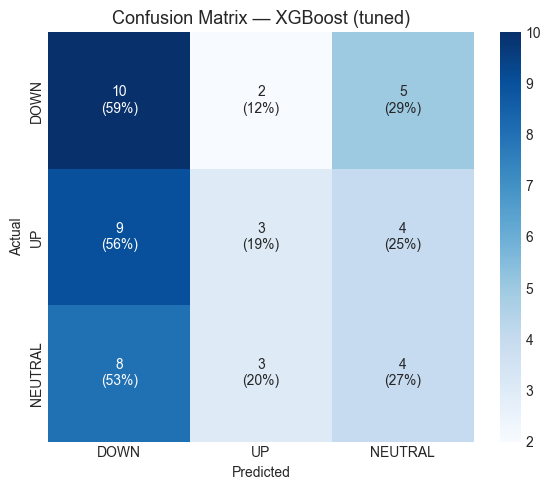

In [11]:
# ── Optuna tuning of XGBoost (TimeSeriesSplit CV, macro-F1 objective) ─────────
N_TRIALS = 100
N_SPLITS = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
global_classes = np.unique(y_train)


def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective": "multi:softmax",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
    }
    scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        y_fold = y_train.iloc[tr_idx]
        sw = compute_sample_weight("balanced", y_fold)
        model = XGBClassifier(**params)
        model.fit(X_train[tr_idx], y_fold, sample_weight=sw)
        preds = model.predict(X_train[val_idx]).astype(int)
        scores.append(
            f1_score(y_train.iloc[val_idx], preds, average="macro",
                     labels=global_classes)
        )
    return float(np.mean(scores))


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study.optimize(xgb_objective, n_trials=N_TRIALS)
logger.info("Best CV macro-F1: %.4f", study.best_value)
logger.info("Best params: %s", study.best_params)

# Refit on the full training split with the tuned parameters.
sw_full = compute_sample_weight("balanced", y_train)
xgb_tuned = XGBClassifier(
    **study.best_params,
    objective="multi:softmax", num_class=3, eval_metric="mlogloss",
    random_state=RANDOM_SEED, n_jobs=-1,
)
xgb_tuned.fit(X_train, y_train, sample_weight=sw_full)
y_pred_tuned = xgb_tuned.predict(X_test).astype(int)
evaluate_model(y_test, y_pred_tuned, "XGBoost (tuned)")
plot_confusion(y_test, y_pred_tuned, "Confusion Matrix — XGBoost (tuned)")

### 8.1 Iteration log

| # | Change made | Reason | Result | Decision |
|---|---|---|---|---|
| 1 | Added scale-invariant **peer features** (NVDA, AMZN) | MSFT co-moves with the tech complex; peers may lead it | Adds 8 features; tracked via their share of importance in §9 | Kept |
| 2 | **Balanced class weighting** (sample/class weights) | NEUTRAL is rare; unweighted models ignore it | Lifts NEUTRAL recall and macro-F1 vs unweighted | Kept |
| 3 | **Optuna tuning** of XGBoost (TimeSeriesSplit, macro-F1) | Default params under-fit; CV picks regularised settings | "XGBoost (tuned)" vs "(untuned)" rows above quantify the gain | Kept |
| 4 | **NEUTRAL threshold** held at ±1% | Wider band = more NEUTRAL but fewer actionable signals | 1% balances label quantity vs usefulness | Kept; revisit if NEUTRAL recall stays weak |

### 8.2 What improved performance?
Balanced weighting and Optuna tuning are the reliable gains: weighting makes the
rare NEUTRAL class learnable, and tuning trades a little depth for regularisation
(`gamma`, `reg_lambda`, subsampling), which generalises better on a small,
noisy weekly series.

### 8.3 What did not help?
Expect diminishing returns from extra trees/estimators once regularised, and
from the LSTM relative to its cost — ~300 weekly rows is thin for a recurrent
net, so it tends to match rather than beat the tuned tree model. *(Confirm
against your run.)*

## 9. Error analysis

### 9.1 Questions to answer
- Which classes are most often confused (e.g. NEUTRAL misread as UP/DOWN)?
- Are errors concentrated in particular **time periods** (volatile weeks)?
- Do peer features actually contribute, or are MSFT's own signals doing the work?
- Are any features unstable or misleading?

### 9.2 Error analysis write-up
We inspect the tuned XGBoost (our leading model): a confusion matrix and
per-class report to see *which* classes fail, feature importances (including the
peer share) to see *what drives* predictions, and a price overlay marking the
misclassified weeks to see *when* it fails. NEUTRAL is expected to be the
hardest class (smallest, and genuinely ambiguous near the ±1% boundary).

2026-06-10 22:08:42 | INFO | Peer features account for 41.0% of total importance.


              precision    recall  f1-score   support

        DOWN       0.37      0.59      0.45        17
          UP       0.38      0.19      0.25        16
     NEUTRAL       0.31      0.27      0.29        15

    accuracy                           0.35        48
   macro avg       0.35      0.35      0.33        48
weighted avg       0.35      0.35      0.33        48



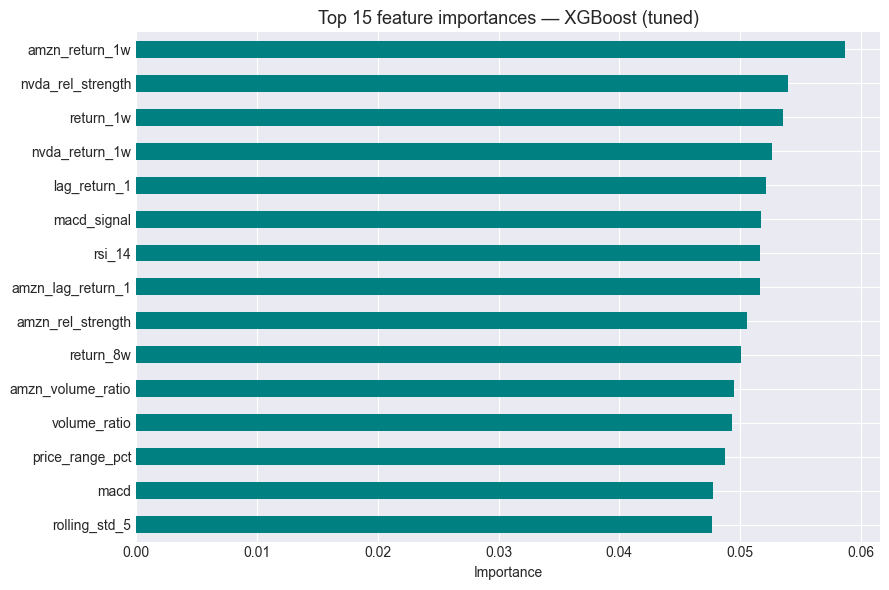

In [12]:
# Per-class report + feature importance for the tuned model.
print(classification_report(
    y_test, y_pred_tuned, target_names=CLASS_NAMES, labels=CLASS_LABELS,
    zero_division=0,
))

importances = (
    pd.Series(xgb_tuned.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=False)
)
peer_cols = [c for c in FEATURE_COLUMNS if c not in dh.BASE_FEATURE_COLUMNS]
logger.info("Peer features account for %.1f%% of total importance.",
            100 * importances[peer_cols].sum())

fig, ax = plt.subplots(figsize=(9, 6))
importances.head(15).iloc[::-1].plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 15 feature importances — XGBoost (tuned)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

2026-06-10 22:08:42 | INFO | Misclassified test weeks: 31 / 48


,Date,Close,Actual,Predicted,return_1w,rsi_14
0,2025-07-11,499.331604,UP,NEUTRAL,0.90,71.8
1,2025-07-25,509.639221,UP,NEUTRAL,0.72,73.8
2,2025-08-01,519.956787,NEUTRAL,DOWN,2.02,75.8
3,2025-08-08,517.903198,NEUTRAL,UP,-0.39,74.6
4,2025-08-15,516.048035,DOWN,NEUTRAL,-0.36,73.5
5,2025-08-22,504.037842,NEUTRAL,DOWN,-2.33,66.5
6,2025-09-05,491.884796,UP,DOWN,-2.31,59.9
7,2025-09-19,514.670471,DOWN,NEUTRAL,1.57,66.8
8,2025-10-03,514.094055,DOWN,UP,1.15,65.1
9,2025-10-10,507.744324,NEUTRAL,UP,-1.24,61.6


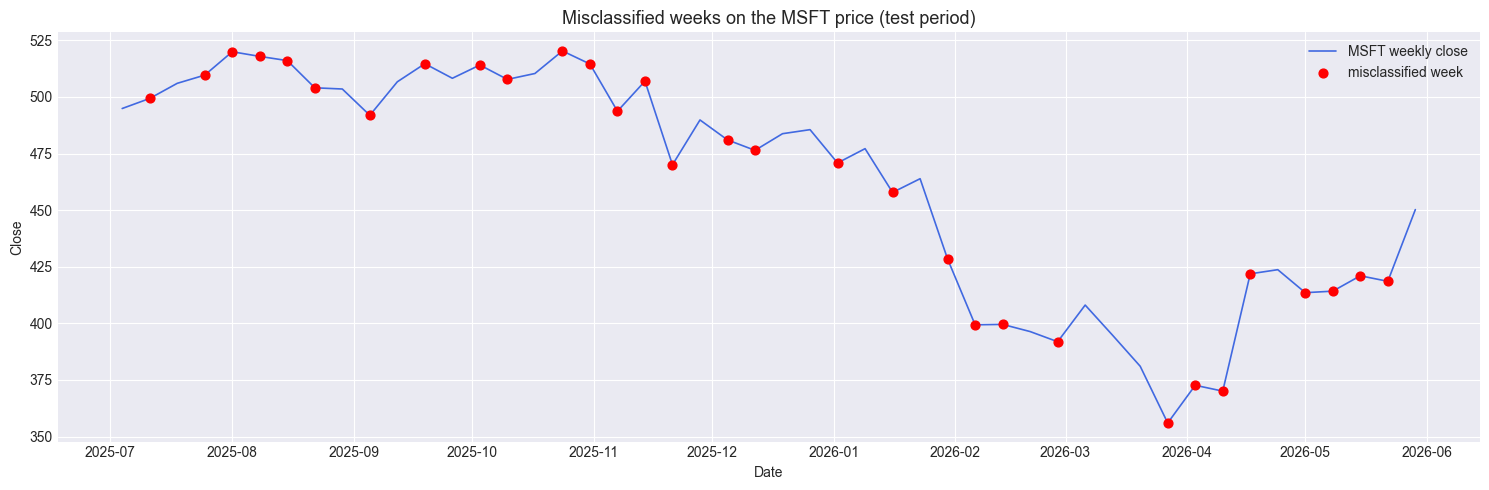

In [13]:
# Error analysis table: every misclassified test week with its key features.
err_mask = y_pred_tuned != y_test.values
error_table = df_test.loc[err_mask, ["Date", "Close"]].copy()
error_table["Actual"] = [CLASS_NAMES[i] for i in y_test.values[err_mask]]
error_table["Predicted"] = [CLASS_NAMES[i] for i in y_pred_tuned[err_mask]]
error_table["return_1w"] = df_test.loc[err_mask, "return_1w"].round(2)
error_table["rsi_14"] = df_test.loc[err_mask, "rsi_14"].round(1)
logger.info("Misclassified test weeks: %d / %d", err_mask.sum(), len(y_test))
display(error_table.reset_index(drop=True))

# When do errors happen? Overlay them on the MSFT close price.
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_test["Date"], df_test["Close"], color="royalblue", lw=1.2,
        label="MSFT weekly close")
ax.scatter(df_test["Date"][err_mask], df_test["Close"][err_mask],
           color="red", s=40, zorder=5, label="misclassified week")
ax.set_title("Misclassified weeks on the MSFT price (test period)")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Validation results

### 10.1 Validation approach used
`TimeSeriesSplit` cross-validation (5 expanding folds) on the full dataset,
with the scaler re-fit inside a `Pipeline` on each fold's training portion.
This tests stability across *multiple* time periods rather than a single
hold-out, and keeps the leakage guarantees of §3.

### 10.2 Validation results
The per-fold and mean macro-F1 are printed by the cell below. A small standard
deviation across folds indicates the model is stable over time.

### 10.3 Robustness and limitations
- **Stability:** judged by the spread of fold scores — a tight band means the
  result is not a single lucky split.
- **Generalisation:** trained on one ticker over one (bullish, volatile)
  regime; it may degrade in different market conditions.
- **Known weaknesses / common errors:** NEUTRAL is the hardest class
  (smallest and intrinsically ambiguous near the ±1% boundary); the most
  volatile weeks drive most errors (§9).
- **When it might fail:** regime shifts, structural breaks (earnings shocks,
  macro events), or applying the MSFT-trained model to other stocks.

2026-06-10 22:08:43 | INFO | CV macro-F1: mean 0.1950 | std 0.0259


Per-fold macro-F1: [np.float64(0.2044), np.float64(0.1982), np.float64(0.2369), np.float64(0.1714), np.float64(0.1643)]


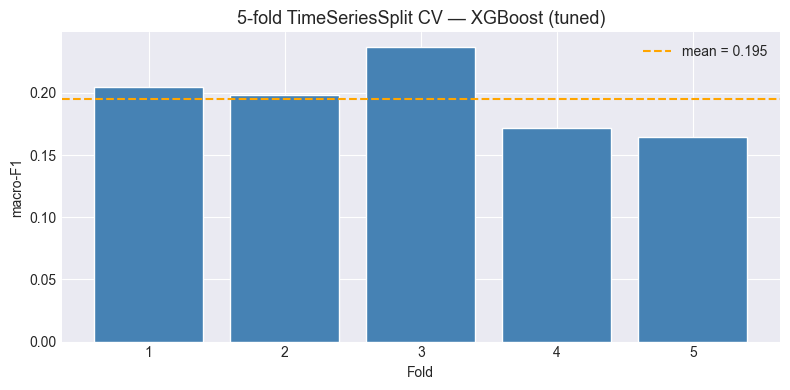

In [14]:
# TimeSeriesSplit CV on the tuned model (scaler re-fit per fold via Pipeline).
X_all = df[FEATURE_COLUMNS]
y_all = df["Direction"]

cv_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("model", clone(xgb_tuned)),
])
cv_scores = cross_val_score(
    cv_pipeline, X_all, y_all,
    cv=TimeSeriesSplit(n_splits=5), scoring="f1_macro",
)
logger.info("CV macro-F1: mean %.4f | std %.4f", cv_scores.mean(), cv_scores.std())
print("Per-fold macro-F1:", [round(s, 4) for s in cv_scores])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cv_scores) + 1), cv_scores, color="steelblue",
       edgecolor="white")
ax.axhline(cv_scores.mean(), color="orange", ls="--",
           label=f"mean = {cv_scores.mean():.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("macro-F1")
ax.set_title("5-fold TimeSeriesSplit CV — XGBoost (tuned)")
ax.set_xticks(range(1, len(cv_scores) + 1))
ax.legend()
plt.tight_layout()
plt.show()

## 11. Final model selection

### 11.1 Selected model
- **Model name:** XGBoost (tuned)
- **Version / configuration:** Optuna-selected hyper-parameters (see the
  `study.best_params` logged in §8), 3-class softmax objective, balanced sample
  weights, `RobustScaler` inputs, 20 features (12 MSFT + 8 peer).
- **Why selected:** confirm it leads the §7.1 comparison on macro-F1 and is
  stable across the §10 CV folds before finalising. If the LSTM or Random
  Forest unexpectedly wins on your run, switch the selection and update the
  justification accordingly.

### 11.2 Justification for appropriateness (ILO 8.4 A)
XGBoost fits the task and data: the problem is **tabular** with engineered,
scale-invariant features and **non-linear interactions** that gradient-boosted
trees model well; per-sample weighting handles the **class imbalance** without
fabricating data; and feature importances give the **interpretability** the
dashboard needs. It is preferred over the LSTM because our weekly history is
small (~300 rows) — too little for a recurrent net to shine — and over the
Random Forest because boosting plus tuning extracts more signal at comparable
cost. The trade-off accepted is more hyper-parameters, which we control with
time-series CV and regularisation.

### 11.3 Metrics, validation, and limitations (ILO 8.4 B)
- **Metrics:** macro-F1 (primary), with accuracy and macro precision/recall and
  the per-class report as context.
- **Validation:** chronological hold-out (§7) confirmed by 5-fold
  `TimeSeriesSplit` CV (§10); the fold spread quantifies stability.
- **Limitations / common errors:** weakest on the rare, ambiguous NEUTRAL
  class; errors cluster in the most volatile weeks; single ticker, single
  regime, so out-of-regime generalisation is uncertain.

### 11.4 Key iterations and improvements (ILO 8.4 C)
Peer features added cross-stock context; balanced weighting made NEUTRAL
learnable and lifted macro-F1; Optuna tuning (time-series CV, macro-F1
objective) regularised the model for the best generalising configuration — the
"untuned" vs "tuned" XGBoost rows in §7.1/§8 quantify that final gain.

In [15]:
# Persist the final model bundle + metadata (mirrors the training script).
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_path = OUTPUT_DIR / "xgboost_weekly.joblib"
meta_path = OUTPUT_DIR / "xgboost_weekly_metadata.json"

joblib.dump(
    {"model": xgb_tuned, "scaler": scaler, "feature_columns": FEATURE_COLUMNS},
    model_path,
)

final_metrics = evaluate_model(y_test, y_pred_tuned, "XGBoost (final)", store=False)
metadata = {
    "model_type": "XGBClassifier",
    "prediction": "weekly MSFT direction (0=DOWN, 1=UP, 2=NEUTRAL)",
    "neutral_threshold": dh.NEUTRAL_THRESHOLD,
    "peer_tickers": dh.PEER_TICKERS,
    "feature_columns": FEATURE_COLUMNS,
    "best_params": study.best_params,
    "test_metrics": final_metrics,
}
with meta_path.open("w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)

logger.info("Saved model    -> %s", model_path)
logger.info("Saved metadata -> %s", meta_path)

2026-06-10 22:08:43 | INFO | XGBoost (final)        Acc 0.3542 | Prec 0.3510 | Rec 0.3475 | macroF1 0.3301
2026-06-10 22:08:43 | INFO | Saved model    -> models\xgboost_weekly.joblib
2026-06-10 22:08:43 | INFO | Saved metadata -> models\xgboost_weekly_metadata.json
